In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import tensorflow as tf

In [2]:
df = tf.keras.datasets.fashion_mnist

In [3]:
(X_train, y_train), (X_test, y_test) = df.load_data()

In [4]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


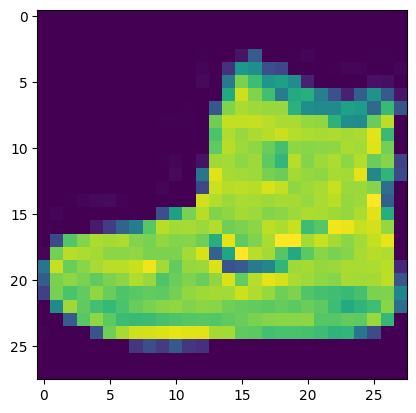

In [5]:
plt.imshow(X_train[0])
plt.show()

In [6]:
X_train = X_train/255.0
X_test = X_test/255.0

X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape = (28,28,1)
    )
)
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

E:\Avdhoot\GitHub\AG1713\Practicals\LP3\ML\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
model.fit(
    X_train,
    y_train,
    epochs=5
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 24ms/step - accuracy: 0.8590 - loss: 0.3938
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 25ms/step - accuracy: 0.9030 - loss: 0.2622
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 74s 21ms/step - accuracy: 0.9173 - loss: 0.2203
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - accuracy: 0.9298 - loss: 0.1877
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.9395 - loss: 0.1627


In [10]:
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [11]:
predicted_class = np.argmax(y_pred[0])
print(predicted_class)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(class_names[predicted_class])

9
Ankle boot


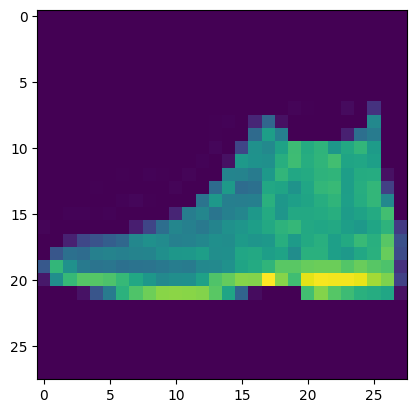

In [12]:
plt.imshow(X_test[0].reshape(28,28))

plt.show()